# EDA on the dataset for game sales.

Written by Matti Hochmann

The video game industry has grown into one of the world’s largest entertainment markets, driven by rapid technological innovation and constantly evolving consumer preferences. For publishers operating in such a competitive environment, understanding the factors that contribute to a game's commercial success is essential for making informed strategic decisions.

This exploratory data analysis (EDA) is conducted from the perspective of a Business Analyst working for a video game publisher. The purpose of this analysis is to uncover meaningful patterns in historical video game sales data that can support business decision-making in areas such as product strategy, platform targeting, market expansion, and performance evaluation.

By examining sales performance across genres, platforms, geographic regions, and critical reception, this study aims to identify the characteristics associated with commercially successful games and provide insights that may help guide future publishing and marketing strategies.

To support this objective, the analysis focuses on the following research questions:

1. How do sales trends differ across geographic regions, and how should publishers adapt their market strategies accordingly?
2. How did sales changed over the years?
3. Is there a meaningful relationship between critic review scores and commercial success in video game sales?

In [1]:
# Importing needed libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
# Loading the csv into pandas DataFrame
sales = pd.read_csv('/kaggle/input/datasets/bhushandivekar/video-game-sales-and-industry-data-1980-2024/Video Games Sales (1980-2024) - Raw.csv')

# Looking at the table to see what it is made of
sales.head()

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,17-09-2013,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,18-11-2014,03-01-2018
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,28-10-2002,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,17-09-2013,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,06-11-2015,14-01-2018


In [3]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  object 
 1   title         64016 non-null  object 
 2   console       64016 non-null  object 
 3   genre         64016 non-null  object 
 4   publisher     64016 non-null  object 
 5   developer     63999 non-null  object 
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  object 
 13  last_update   17879 non-null  object 
dtypes: float64(6), object(8)
memory usage: 6.8+ MB


## Dataset Overview

This dataset contains detailed information about video game titles and their sales performance across different regions worldwide.  
Each row represents a single video game, and all sales values are measured in millions of units sold.


| Column         | Description                                                      | Variable Type |
|----------------|------------------------------------------------------------------|----------------|
| `img`          | URL or path to the game image                                    | object |
| `title`        | Name of the video game                                           | object |
| `console`      | Gaming platform (e.g., PS2, Xbox, PC)                            | object |
| `genre`        | Game genre                                                       | object |
| `publisher`    | Publishing company                                               | object |
| `developer`    | Game developer                                                   | object |
| `critic_score` | Review or critic score assigned to the game                      | float64 |
| `total_sales`  | Total global sales                                               | float64 |
| `na_sales`     | Sales in North America                                           | float64 |
| `jp_sales`     | Sales in Japan                                                   | float64 |
| `pal_sales`    | Sales in PAL regions (primarily Europe and Australia)            | float64 |
| `other_sales`  | Sales in other regions                                           | float64 |
| `release_date` | Original release date                                            | object |
| `last_update`  | Date of the latest dataset update                                | object |


The dataset also contains missing values in several columns, particularly in sales-related features and critic scores, which may require cleaning or preprocessing before analysis.


In [4]:
# Looking for missing values
print(f"Dataset Shape: {sales.shape[0]} rows × {sales.shape[1]} columns")

missing = sales.isnull().sum()
missing_pct = (missing / len(sales) * 100).round(2)
summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
display(summary[summary['Missing Count'] > 0])

Dataset Shape: 64016 rows × 14 columns


,Missing Count,Missing %
developer,17,0.03
critic_score,57338,89.57
total_sales,45094,70.44
na_sales,51379,80.26
jp_sales,57290,89.49
pal_sales,51192,79.97
other_sales,48888,76.37
release_date,7051,11.01
last_update,46137,72.07


**Only a relatively small portion of the dataset contains complete sales information.**

**Most missing values are concentrated in the critic score and sales-related columns, indicating that many games were not fully documented. As a result, the dataset may contain bias, which could affect the reliability and accuracy of subsequent analyses.**

## Data Cleaning

Rows containing missing critic scores or sales data will be removed, as incomplete records limit the ability to perform meaningful comparisons and reliable analysis across games.

In [5]:
# Removing rows without sales data
print(f"Removing {sales['total_sales'].isna().sum()} rows of partial data.")
sales = sales.dropna(subset='total_sales')
# Removing the picture column and the last update column
sales = sales.drop(columns=['img', 'last_update'])

Removing 45094 rows of partial data.


After removing rows with missing key variables, the remaining data provides a reliable basis for analysis.

In [6]:
sales['release_date'] = pd.to_datetime(sales['release_date'], format='%d-%m-%Y', errors='raise')

**The release_date column was converted from an object (string) type to a proper datetime format. This change allows the dates to be interpreted correctly and makes it possible to perform time-based analysis, such as sorting, filtering, and extracting temporal trends.**

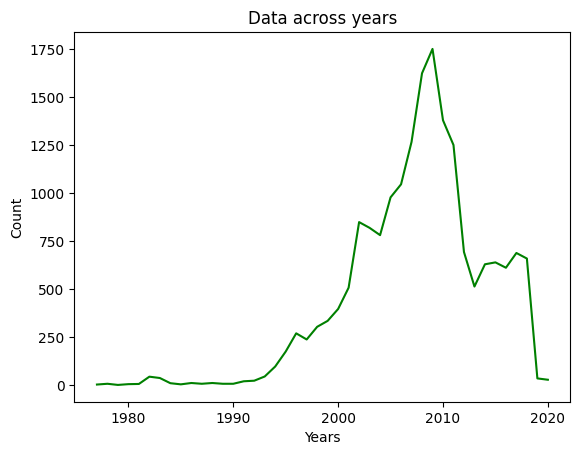

In [7]:
sales['year'] = sales['release_date'].dt.year
year_count = sales['year'].value_counts().sort_index()

plt.plot(year_count.index, year_count.values, color='green')
plt.xlabel('Years')
plt.ylabel('Count')
plt.title('Data across years')
plt.show()

The dataset includes games released as early as the late 1970s, but records prior to 2001 are relatively sparse and represent an industry environment that differs significantly from the modern video game market.

Since this analysis is conducted from the perspective of a business analyst at a video game publisher, the focus should remain on data that reflects commercially relevant market conditions. The year 2001 was selected as a cutoff point because it marks the beginning of a more modern gaming era, characterized by the expansion of major console ecosystems and large-scale publishing strategies.

Therefore, only games released from 2001 onward are included in the analysis.

In [8]:
sales = sales[sales['release_date'] >= '2001-01-01']

In [9]:
sales[sales.duplicated(subset=['title', 'console', 'release_date'], keep=False)]\
    .sort_values(['title', 'console', 'release_date'])

,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,year
13461,Akko ni Omakase! Brain Shock,DS,Misc,Taito,Taito,NaN,0.04,NaN,0.04,NaN,NaN,2006-12-07,2006.0
13536,Akko ni Omakase! Brain Shock,DS,Misc,Taito,Taito Corporation,NaN,0.04,NaN,0.04,NaN,NaN,2006-12-07,2006.0
5772,Assassin's Creed: Altair's Chronicles,DS,Action,Ubisoft,Gameloft,NaN,0.27,0.27,NaN,NaN,NaN,2008-02-05,2008.0
13258,Assassin's Creed: Altair's Chronicles,DS,Action,Ubisoft,Gameloft,5.7,0.05,0.03,NaN,0.01,0.00,2008-02-05,2008.0
18413,Battle of the Bands,Wii,Misc,THQ,Planet Moon Studios,NaN,0.00,0.00,NaN,0.00,NaN,2008-04-21,2008.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18295,Smart Kid's Gameclub,DS,Misc,UFO Interactive,Tommo,NaN,0.00,0.00,NaN,NaN,0.00,2007-11-16,2007.0
8648,Touch My Katamari,PSV,Puzzle,Namco Bandai Games,Namco Bandai Games,NaN,0.14,0.07,NaN,0.04,0.03,2012-02-21,2012.0
15753,Touch My Katamari,PSV,Puzzle,Namco Bandai,Namco Bandai,NaN,0.02,0.01,0.01,0.00,NaN,2012-02-21,2012.0
2438,Zaidan Houjin Nippon Kanji Nouryoku Kentei Kyo...,DS,Misc,IE Institute,IE Institute,NaN,0.66,NaN,0.66,NaN,NaN,2006-11-09,2006.0


When duplicate entries were identified, the version containing the most complete business-relevant information (sales and review metrics) will be retained.

In [10]:
important_cols = [
    'critic_score',
    'na_sales',
    'pal_sales',
    'jp_sales',
    'other_sales',
    'total_sales'
]

sales['completeness_score'] = sales[important_cols].notna().sum(axis=1)

sales = (
    sales.sort_values('completeness_score', ascending=False)
      .drop_duplicates(subset=['title', 'console', 'release_date'], keep='first')
      .drop(columns='completeness_score')
)

**The next step verifies whether the total_sales column is consistent with the sum of regional sales (NA, JP, PAL, and Other). In other words, it checks the internal validity of the dataset by confirming that the reported total sales correctly reflect the combined regional figures.**

In [11]:
sales['added_sales'] = (sales['na_sales'] + sales['jp_sales'] + sales['pal_sales'] + sales['other_sales'])
sales['difference'] = sales['total_sales'] - sales['added_sales']
(sales['difference'] == 0).all()

np.False_

**The calculated difference (delta) is not zero, indicating a discrepancy between `total_sales` and the sum of regional sales. This suggests that the reported total sales do not perfectly align with the aggregated regional values. The next step is to investigate the possible causes of this inconsistency.**

In [12]:
sales['difference'].describe()

count    1.999000e+03
mean    -3.001501e-05
std      6.514717e-03
min     -2.000000e-02
25%     -1.110223e-16
50%      0.000000e+00
75%      8.326673e-17
max      2.000000e-02
Name: difference, dtype: float64

The summary statistics for the discrepancy show that the differences between `total_sales` and the sum of regional sales are extremely small, effectively centered around zero. The mean is close to zero, and both the median and interquartile range are essentially negligible, with only tiny deviations on the order of (10^{-2}) or smaller.

This strongly suggests that the observed mismatch is not meaningful from an analytical perspective, but rather the result of floating-point precision or rounding errors during data storage or computation. In practical terms, the total sales values can be considered consistent with the sum of regional sales.

In [13]:
console_merge = {
    "PS3": "PS",
    "PS4": "PS",
    "PS2": "PS",
    "X360": "XBOX",
    "XOne": "XBOX",
    "PSP": "PS",
    "Wii": "Nintendo",
    "DS": "Nintendo",
    "GBA": "Nintendo",
    "XB": "XBOX",
    "PSN": "PS",
    "PSV": "PS",
    "N64": "Nintendo",
    "GBC": "Nintendo",
    "GC": "Nintendo",
    "NS": "Nintendo",
    "3DS": "Nintendo",
    "DC": "Sega",
    "GB": "Nintendo",
    "WiiU": "Nintendo",
    "WS": "WonderSwan",
    "VC": "Nintendo",
    "WW": "Nintendo",
    "SAT": "Sega",
    "XBL": "XBOX",
    "OSX": "PC",
    "Mob": "Mobile",
    "PS": "PS",
    "PC": "PC",
}

sales['console_family'] = sales['console'].map(console_merge)

In [14]:
publisher_merge = {
    'Microsoft Game Studios': 'Microsoft',
    'Microsoft Studios': 'Microsoft',
    'Sony Computer Entertainment': 'Sony',
    'Sony Computer Entertainment America': 'Sony',
    'Sony Computer Entertainment Europe': 'Sony',
    'Sony Interactive Entertainment': 'Sony',
    'Sony Online Entertainment': 'Sony',
    'Sony Music Entertainment': 'Sony',
    '989 Studios': 'Sony',
    'EA Sports': 'Electronic Arts',
    'EA Sports BIG': 'Electronic Arts',
    'Activision Value': 'Activision',
    'Konami Digital Entertainment': 'Konami',
    'Namco': 'Bandai Namco',
    'Bandai': 'Bandai Namco',
    'Namco Bandai': 'Bandai Namco',
    'Namco Bandai Games': 'Bandai Namco',
    'Bandai Namco Games': 'Bandai Namco',
    'Bandai Namco Entertainment': 'Bandai Namco',
    'Square': 'Square Enix',
    'SquareSoft': 'Square Enix',
    'Square EA': 'Square Enix',
    'Enix': 'Square Enix',
    'Warner Bros. Interactive': 'Warner Bros.',
    'Warner Bros. Interactive Entertainment': 'Warner Bros.',
    'Disney Interactive Studios': 'Disney',
    'Buena Vista': 'Disney',
    'LEGO Media': 'Disney',
    '2K Sports': '2K',
    '2K Games': '2K',
    '2K Play': '2K',
    'THQ Nordic': 'THQ',
    'Majesco Entertainment': 'Majesco',
    'Milestone S.r.l.': 'Milestone',
    'Milestone S.r.l': 'Milestone',
    'Marvelous Interactive': 'Marvelous',
    'Marvelous Entertainment': 'Marvelous',
    'Capcom Entertainment': 'Capcom',
    'Eidos Interactive Ltd': 'Eidos Interactive',
    'KOEI': 'Koei Tecmo',
    'Tecmo': 'Koei Tecmo',
    'Tecmo Koei': 'Koei Tecmo',
    'AQ Interactive': 'Koei Tecmo',
    'Infogrames': 'Atari',
    'Nippon Ichi Software': 'NIS America',
    'Falcom Corporation': 'Nihon Falcom',
    'Nihon Falcom Corp': 'Nihon Falcom',
    'Nihon Falcom Corporation': 'Nihon Falcom',
    'D3 Publisher': 'D3Publisher',
    'Team17 Software': 'Team17',
    'Team17 Digital Ltd': 'Team17',
    'Team 17': 'Team17',
    'Paon Corporation': 'Paon',
    'Idea Factory International': 'Idea Factory',
    'Otomate Idea Factory': 'Idea Factory',
    'Rising Star Games': 'Rising Star',
    'O~3 Entertainment': 'O3 Entertainment',
}

sales['publisher_conglomerate'] = sales['publisher'].replace(publisher_merge)

In [15]:
developer_merge = {

    # === ROCKSTAR ===
    'DMA Design': 'Rockstar',
    'Rockstar Games': 'Rockstar',
    'Rockstar North': 'Rockstar',
    'Rockstar San Diego': 'Rockstar',
    'Rockstar Leeds': 'Rockstar',
    'Rockstar Leeds/North': 'Rockstar',
    'Rockstar Vancouver': 'Rockstar',
    'Rockstar London': 'Rockstar',
    'Rockstar Toronto': 'Rockstar',
    'Rockstar Toronto / Leeds': 'Rockstar',

    # === ELECTRONIC ARTS ===
    'EA': 'Electronic Arts',
    'EA Vancouver': 'Electronic Arts',
    'EA Canada': 'Electronic Arts',
    'EA Sports': 'Electronic Arts',
    'EA DICE': 'Electronic Arts',
    'EA Redwood Shores': 'Electronic Arts',
    'EA Black Box': 'Electronic Arts',
    'EA Los Angeles': 'Electronic Arts',
    r'EA Los Angeles\ Westwood Studios': 'Electronic Arts',
    'EA Tiburon': 'Electronic Arts',
    'EA Seattle': 'Electronic Arts',
    'EA Chicago': 'Electronic Arts',
    'EA Montreal': 'Electronic Arts',
    'EA Salt Lake': 'Electronic Arts',
    'EA UK': 'Electronic Arts',
    'EA Bright Light': 'Electronic Arts',
    'EA Bright Light Productions': 'Electronic Arts',
    'EA Japan Studio': 'Electronic Arts',
    'EA Freestyle': 'Electronic Arts',
    'EA Pacific': 'Electronic Arts',
    'EA Phenomic': 'Electronic Arts',
    'EA Games': 'Electronic Arts',
    'EA Digital Illusions CE': 'Electronic Arts',
    'Electronic Arts North Carolina': 'Electronic Arts',
    'Electronic Arts UK': 'Electronic Arts',
    'Electronic Arts Casual Studios': 'Electronic Arts',
    'DICE': 'Electronic Arts',
    'Digital Illusions': 'Electronic Arts',
    'Digital Illusions CE': 'Electronic Arts',
    'Digtal Illusions': 'Electronic Arts',      # typo
    'Digital Illusions (DICE)': 'Electronic Arts',
    'Maxis': 'Electronic Arts',
    'Maxis Software': 'Electronic Arts',
    'The Sims Studio': 'Electronic Arts',
    'Visceral Games': 'Electronic Arts',
    'Ghost Games': 'Electronic Arts',
    'Criterion Games': 'Electronic Arts',
    'Criterion': 'Electronic Arts',

    # === UBISOFT ===
    'Ubisoft Montreal': 'Ubisoft',
    'Ubisoft Montpellier': 'Ubisoft',
    'UBIart Montpellier': 'Ubisoft',
    'Ubisoft Paris': 'Ubisoft',
    'Ubisoft Quebec': 'Ubisoft',
    'Ubisoft Quebec City': 'Ubisoft',
    'Ubisoft San Francisco': 'Ubisoft',
    'Ubisoft Sofia': 'Ubisoft',
    'Ubisoft Shanghai': 'Ubisoft',
    'Ubisoft Reflections': 'Ubisoft',
    'Reflections Interactive': 'Ubisoft',
    'Ubisoft Romania': 'Ubisoft',
    'Ubisoft Annecy': 'Ubisoft',
    'Ubisoft Toronto': 'Ubisoft',
    'Ubisoft Barcelona': 'Ubisoft',
    'Ubisoft Vancouver': 'Ubisoft',
    'Ubisoft Milan': 'Ubisoft',
    'Ubisoft Casablanca': 'Ubisoft',
    'Ubisoft Bucharest': 'Ubisoft',
    'Ubisoft Sao Paulo': 'Ubisoft',
    'Ubisoft Nagoya': 'Ubisoft',
    'Ubi Nagoya': 'Ubisoft',
    'Ubisoft Pune': 'Ubisoft',
    'Ubisoft Barcelona / Inland Productions': 'Ubisoft',
    'Ubisoft Montreal / Annecy': 'Ubisoft',
    'Ubisoft Barcelona / Ubisoft Reflections': 'Ubisoft',
    'Ubisoft Montreal / Red Storm Entertainment': 'Ubisoft',
    'Blue Byte Studio': 'Ubisoft',
    'Blue Byte': 'Ubisoft',
    'Massive Entertainment': 'Ubisoft',
    'High Moon Studios': 'Ubisoft',
    'Red Storm Entertainment': 'Ubisoft',
    'Red Storm Entertainment / Ubisoft Paris': 'Ubisoft',

    # === KONAMI ===
    'Konami Computer Entertainment Tokyo': 'Konami',
    'Konami Computer Entertainment Japan': 'Konami',
    'Konami Computer Entertainment Hawaii': 'Konami',
    'Konami Computer Entertainment Osaka': 'Konami',
    'Konami Computer Entertainment Nagoya': 'Konami',
    'Konami Computer Entertainment America': 'Konami',
    'Konami Digital Entertainment': 'Konami',
    'Konami Software Shanghai': 'Konami',
    'Konami / Eighting': 'Konami',
    'KCET': 'Konami',
    'KCEJ': 'Konami',
    'KCEO': 'Konami',
    'KCEA': 'Konami',
    'KCEK': 'Konami',
    'KCE Studios': 'Konami',
    'KCE Tokyo Inc': 'Konami',
    'KCEJ': 'Konami',

    # === BANDAI NAMCO ===
    'Namco': 'Bandai Namco',
    'Namco Bandai': 'Bandai Namco',
    'Namco Bandai Games': 'Bandai Namco',
    'Namco Bandai Games America': 'Bandai Namco',
    'Bandai Namco Games': 'Bandai Namco',
    'Bandai': 'Bandai Namco',
    'Namco Tales Studio': 'Bandai Namco',
    'Bandai Namco Studios': 'Bandai Namco',
    'Spike / Bandai Namco Games': 'Bandai Namco',
    'Bandai Namco Games / Celius': 'Bandai Namco',

    # === SQUARE ENIX ===
    'Square': 'Square Enix',
    'SquareSoft': 'Square Enix',
    'Square Enix / Bones': 'Square Enix',

    # === CAPCOM ===
    'Capcom Entertainment': 'Capcom',
    'Capcom Production Studio 1': 'Capcom',
    'Capcom Production Studio 2': 'Capcom',
    'Capcom Production Studio 4': 'Capcom',
    'Capcom Production Studio 6': 'Capcom',
    'Capcom Production Studio 8': 'Capcom',
    'Capcom Production Studio 1 / TOSE Software': 'Capcom',
    'Capcom / Dimps Corporation': 'Capcom',

    # === SEGA ===
    'Sega-AM2': 'Sega',
    'Sega-AM3': 'Sega',
    'Sega WOW Overworks': 'Sega',
    'Sega Sports R&D': 'Sega',
    'Sega CS3': 'Sega',
    'Sega Rosso': 'Sega',
    'Sega Racing Studio': 'Sega',
    'Sega Studios Australia': 'Sega',
    'Sega Europe': 'Sega',
    'Sonic Team': 'Sega',
    'Hitmaker': 'Sega',
    'Amusement Vision': 'Sega',
    'Overworks': 'Sega',

    # === BIOWARE ===
    'BioWare Edmonton': 'BioWare',
    'BioWare Corp.': 'BioWare',
    'BioWare / Demiurge Studios': 'BioWare',

    # === 2K ===
    '2K Sports': '2K',
    '2K Games': '2K',
    '2K Play': '2K',
    '2K Marin': '2K',
    '2K Czech': '2K',
    '2K Shanghai': '2K',
    '2K Australia / 2K Boston': '2K',
    '2K Boston / 2K Australia': '2K',
    '2K Boston / 2K Australia / 2K Marin': '2K',

    # === BUNGIE ===
    'Bungie Studios': 'Bungie',
    'Bungie West': 'Bungie',

    # === YUKE'S ===
    "Yuke's Media Creations": "Yuke's",
    "Yuke's Future Media Creators": "Yuke's",
    "Yuke's Osaka": "Yuke's",
    "Yukie's Osaka": "Yuke's",   # typo

    # === NEVERSOFT ===
    'Neversoft Entertainment': 'Neversoft',
    'Neversoft Entertainment / Rebellion': 'Neversoft',

    # === AKI CORPORATION ===
    'AKI Corporation / EA Canada': 'AKI Corporation',
    'Aki Corp.': 'AKI Corporation',
    'Aki Corp': 'AKI Corporation',

    # === MIDWAY ===
    'Midway Games': 'Midway',
    'Midway Games West': 'Midway',
    'Midway Amusement Games': 'Midway',
    'Midway Studios San Diego': 'Midway',
    'Midway Studios Los Angeles': 'Midway',
    'Midway Studios Newcastle': 'Midway',
    'Midway Studios Austin': 'Midway',
    'Midway Studios  Austin': 'Midway',    # double space typo
    'Midway Studios - Austin': 'Midway',

    # === SONY INTERNAL STUDIOS ===
    'SCE San Diego Studio': 'Sony Interactive Entertainment',
    'SIE San Diego Studio': 'Sony Interactive Entertainment',
    'SCEA San Diego Studios': 'Sony Interactive Entertainment',
    'SCEA Bend Studio': 'Sony Interactive Entertainment',
    'SCEA Bend Studio / Naughty Dog': 'Sony Interactive Entertainment',
    'SCEA Santa Monica Studio': 'Sony Interactive Entertainment',
    'SIE London Studio': 'Sony Interactive Entertainment',
    'SIE Japan Studio': 'Sony Interactive Entertainment',
    'SCE Japan Studio': 'Sony Interactive Entertainment',
    'SCEE London Studio': 'Sony Interactive Entertainment',
    'SCEE Cambridge': 'Sony Interactive Entertainment',
    'SCEI': 'Sony Interactive Entertainment',
    'SCEA': 'Sony Interactive Entertainment',
    'SCEE': 'Sony Interactive Entertainment',
    'Sony Computer Entertainment America': 'Sony Interactive Entertainment',
    'Sony Computer Entertainment Japan': 'Sony Interactive Entertainment',
    'Sony Online Entertainment': 'Sony Interactive Entertainment',
    '989 Sports': 'Sony Interactive Entertainment',
    'Eidetic': 'Sony Interactive Entertainment',
    'London Studios': 'Sony Interactive Entertainment',
    'SCEE London Studio / Zoe Mode': 'Sony Interactive Entertainment',
    'PlayStation C.A.M.P.!': 'Sony Interactive Entertainment',
    'Polyphony Digital': 'Sony Interactive Entertainment',

    # === KOEI TECMO ===
    'Koei': 'Koei Tecmo',
    'Tecmo': 'Koei Tecmo',
    'Tecmo Koei Games': 'Koei Tecmo',
    'Tecmo Koei Canada': 'Koei Tecmo',
    'Omega Force': 'Koei Tecmo',
    'Omega Force / Koei Canada': 'Koei Tecmo',
    'Koei Canada': 'Koei Tecmo',
    'Koei/Inis': 'Koei Tecmo',
    'Koei / Inis': 'Koei Tecmo',

    # === SNK ===
    'SNK Playmore': 'SNK',
    'SNK Playmore Corporation': 'SNK',
    'SNK Corporation': 'SNK',

    # === MILESTONE ===
    'Milestone S.r.l.': 'Milestone',
    'Milestone S.r.l': 'Milestone',
    'MileStone Inc.': 'Milestone',

    # === MARVELOUS ===
    'Marvelous Interactive': 'Marvelous',
    'Marvelous Entertainment': 'Marvelous',
    'Marvelous Games': 'Marvelous',
    'Marvelous / Imageepoch': 'Marvelous',

    # === ACTIVISION ===
    'Activision Value': 'Activision',

    # === RARE ===
    'Rare Ltd.': 'Rare',

    # === TAKE-TWO ===
    'Take 2 Interactive': 'Take-Two Interactive',

    # === SUCKER PUNCH ===
    'Sucker Punch': 'Sucker Punch Productions',

    # === WAYFORWARD ===
    'WayForward Technologies': 'WayForward',
    'Way Forward Technologies': 'WayForward',
    'WayForward Pocket Team': 'WayForward',
    'Way Forward': 'WayForward',

    # === HUDSON ===
    'Hudson': 'Hudson Soft',

    # === FRONTIER ===
    'Frontier Studio': 'Frontier Developments',

    # === TURN 10 ===
    'Turn 10 Studio': 'Turn 10 Studios',   # typo

    # === NIHON FALCOM ===
    'Falcom': 'Nihon Falcom',
    'Nihon Falcom Corporation': 'Nihon Falcom',

    # === DIMPS ===
    'Dimps Corporation': 'Dimps',
    'Dimps Corporation / Sonic Team': 'Dimps',
    'Dimps Corporation / Amusement Vision': 'Dimps',
    'Sonic Team/Dimps Corporation': 'Dimps',

    # === CD PROJEKT RED ===
    'CD Projekt Red Studio': 'CD Projekt Red',

    # === VOLITION ===
    'Volition Inc.': 'Volition',

    # === BEHAVIOUR INTERACTIVE ===
    'Behaviour Interactive Inc.': 'Behaviour Interactive',
    'Behaviour Studios': 'Behaviour Interactive',

    # === GRIPTONITE ===
    'Griptonite Studio': 'Griptonite Games',
    'Griptonite': 'Griptonite Games',
    'Amaze Entertainment / Griptonite Games': 'Griptonite Games',

    # === POPCAP ===
    'PopCap': 'PopCap Games',

    # === CYANIDE ===
    'Cyanide Studio': 'Cyanide Studios',
    'Cyanide': 'Cyanide Studios',

    # === FIRAXIS ===
    'Firaxis': 'Firaxis Games',

    # === SPIKE CHUNSOFT ===
    'Spike Co.': 'Spike',
    'Spike / DreamFactory Ltd.': 'Spike',

    # === TEAM 17 ===
    'Team17 Software': 'Team17',
    'Team17 Digital Ltd': 'Team17',
    'Team 17': 'Team17',

    # === ATARI ===
    'Atari Games': 'Atari',
}

sales['developer_family'] = sales['developer'].replace(developer_merge)

# EDA

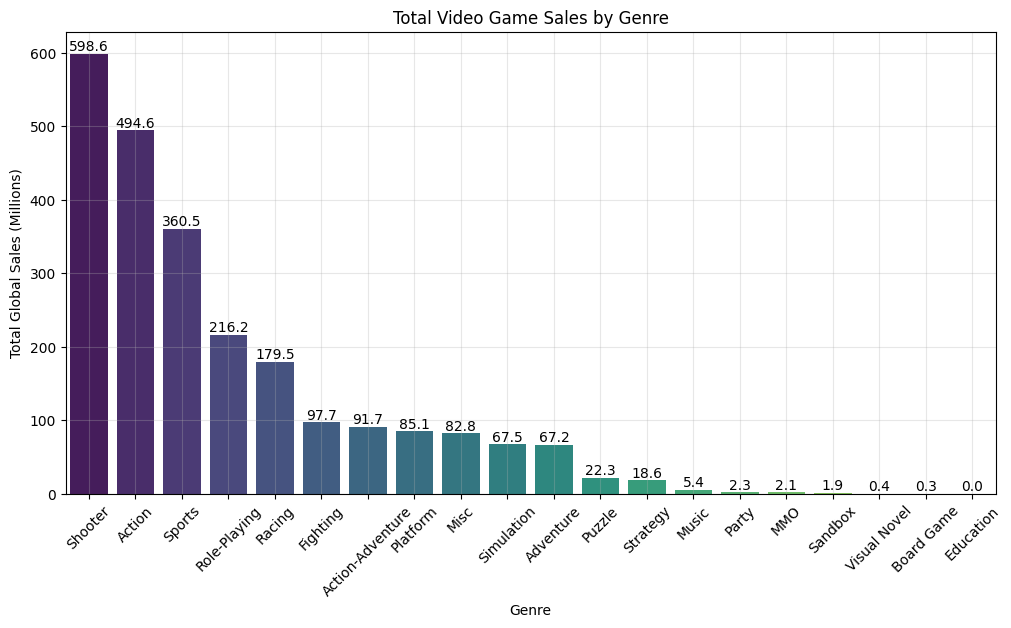

In [16]:
# Showing visually the top selling genres, comparatively

genre_sales = (
    sales.groupby('genre')['added_sales']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
sns.barplot(
    x=genre_sales.index,
    y=genre_sales.values,
    hue=genre_sales.index,
    palette="viridis"
)

plt.title("Total Video Game Sales by Genre")
plt.xlabel("Genre")
plt.ylabel("Total Global Sales (Millions)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)


for i, v in enumerate(genre_sales.values):
    plt.text(i, v, f"{v:.1f}", ha='center', va='bottom')

plt.show()

It is visibly clear to see that: Action and Shooter genres dominate global sales, indicating strong mass-market appeal. These genres likely benefit from broader audience accessibility and replayability compared to niche categories such as Puzzle or Strategy. This suggests that studios targeting large-scale commercial success should prioritize these genres, especially when aiming for global markets.

## How are video game sales split across different global regions?

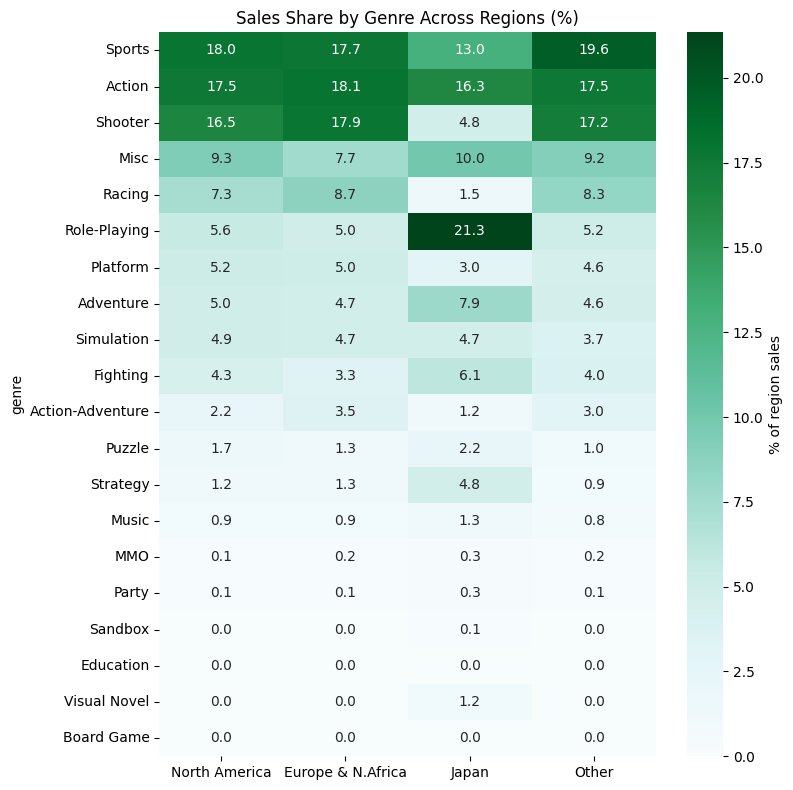

In [17]:
regions = sales.groupby('genre')[['na_sales', 'pal_sales', 'jp_sales', 'other_sales']].sum()
regions.columns = ['North America', 'Europe & N.Africa', 'Japan', 'Other']

# Normalize per region (each column sums to 100%) - shows share within region
regions_pct = regions.div(regions.sum()) * 100

plt.figure(figsize=(8, 8))
sns.heatmap(regions_pct.sort_values('North America', ascending=False),
            annot=True, fmt='.1f', cmap='BuGn', cbar_kws={'label': '% of region sales'})
plt.title('Sales Share by Genre Across Regions (%)')
plt.tight_layout()
plt.show()

This visualization shows the distribution of video game sales by genre across different regions.

Each column represents a region, highlighting how player preferences vary geographically.  
It seems most preferences are the same within each area. Only major exception being Role-Playing games in Japan.

**Apart from Japan's preference to RPG's, regional differences are not significant. Indicating similarty across the board for genre success.**

## How did sales improved over the years?

In [18]:
# Isolating the year from date column
sales['release_year'] = sales['release_date'].dt.year

top_consoles = (sales.groupby('console_family')['added_sales'].sum().sort_values(ascending=False).head(5).index)

# Constructing data of the 5 best selling consoles, summed by year
sales_by_console = sales[sales['console_family'].isin(top_consoles)]
sales_by_year_console = sales_by_console.groupby(['release_year', 'console_family'])['added_sales'].sum().reset_index()

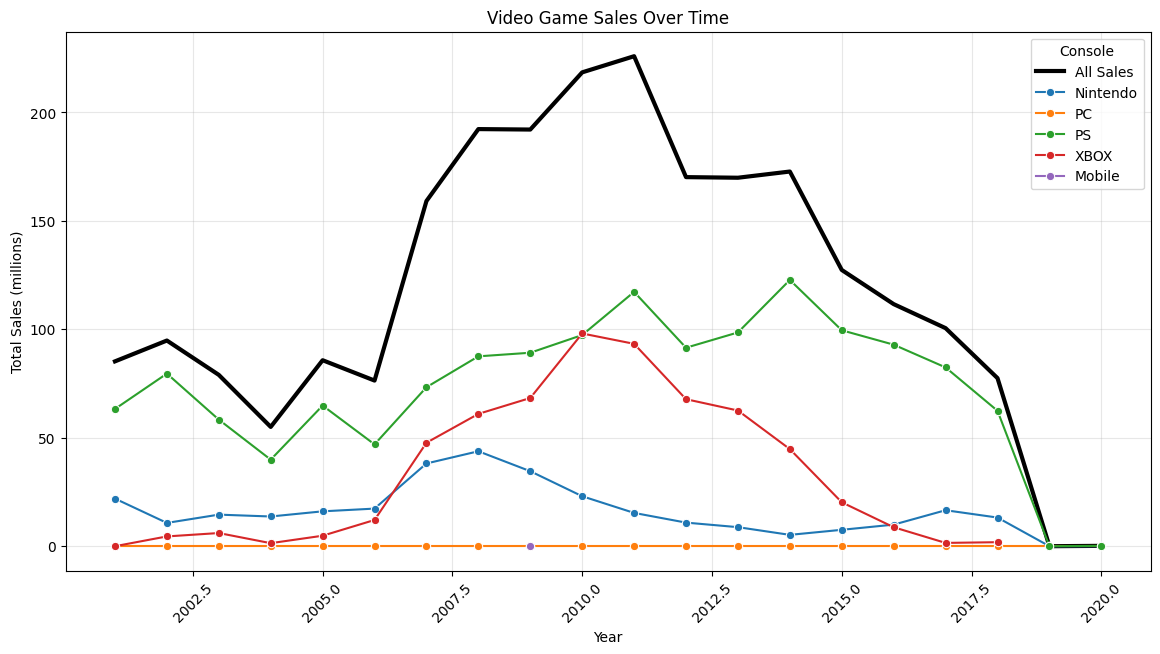

In [19]:
# Plotting lines for the top 5 best selling console sales, along with total sales, over yearly timeline
plt.figure(figsize=(14,7))
sns.lineplot(data=sales.groupby('release_year')['added_sales'].sum().reset_index(), x='release_year', y='added_sales', color='black', label='All Sales',  linewidth=3)
sns.lineplot(data=sales_by_year_console, x='release_year', y='added_sales', hue='console_family', marker='o')

plt.title("Video Game Sales Over Time")
plt.xlabel("Year")
plt.ylabel("Total Sales (millions)")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend(title='Console')
plt.show()

1. The gaming market shows a clear growth phase followed by a decline after its peak, likely reflecting console generation cycles and market saturation.

2. Platform transitions appear to play a major role in market dynamics, with sales peaking during mature console generations and dropping during transition periods.

3. This suggests that timing a game’s release within a platform’s lifecycle is critical-launching too late may limit sales potential as the user base shifts to newer systems.

## What scores are given to games?

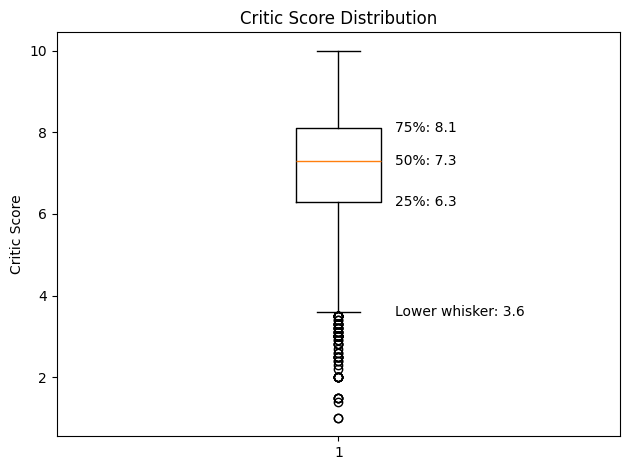

In [20]:
data = sales['critic_score'].dropna()

fig, ax = plt.subplots()
bp = ax.boxplot(data)

# Quartiles
q1 = np.percentile(data, 25)
median = np.percentile(data, 50)
q3 = np.percentile(data, 75)

# IQR and whiskers
iqr = q3 - q1
lower_whisker = data[data >= (q1 - 1.5 * iqr)].min()

# Labels
ax.text(1.1, q3, f'75%: {q3:.1f}', va='center')
ax.text(1.1, median, f'50%: {median:.1f}', va='center')
ax.text(1.1, q1, f'25%: {q1:.1f}', va='center')
ax.text(1.1, lower_whisker, f'Lower whisker: {lower_whisker:.1f}', va='center')

plt.title('Critic Score Distribution')
plt.ylabel('Critic Score')
plt.tight_layout()
plt.show()

### Critic Score Distribution - Insights

-  **Median score is ~7.3** - indicating a generally fair to good critical reception
-  **Relatively narrow IQR (~2 points)** between the 25th and 75th percentiles, suggesting a general consensus among critics for most games

> Most games received average to good reviews, but there is a tail of particularly low-scoring games - **worth investigating who they are and why.**

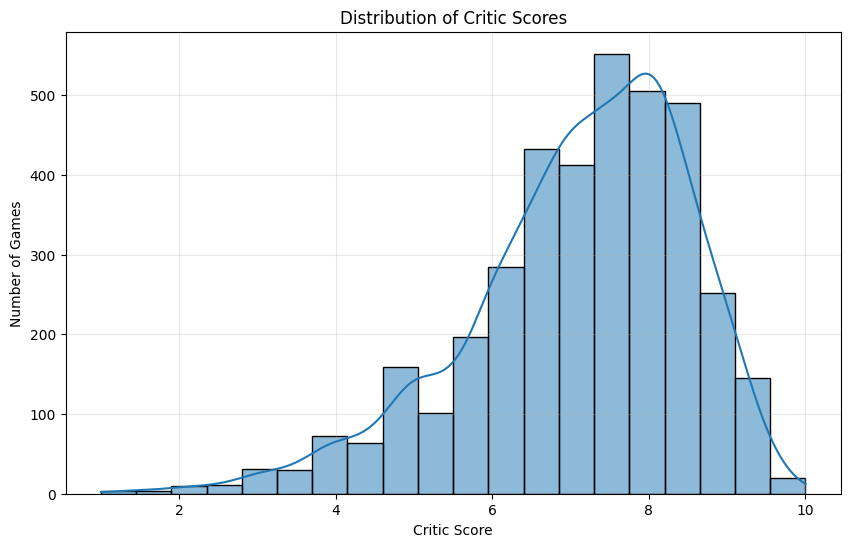

In [21]:
# Showing the game scores divided between 20 scales
plt.figure(figsize=(10,6))

sns.histplot(sales['critic_score'].dropna(), bins=20, kde=True)

plt.title("Distribution of Critic Scores")
plt.xlabel("Critic Score")
plt.ylabel("Number of Games")
plt.grid(alpha=0.3)

plt.show()

The distribution is slightly left-skewed, meaning most games receive relatively high critic scores. The majority of values are concentrated above average, suggesting that games are generally reviewed positively. The peak appears around the mid-to-high range (around 70–80 on a 100-point scale), which may indicate that most releases fall into the “good but not exceptional” category.

## What is the relation between game's score and game's sales?

In [22]:
# Removing emptry entris
scored_sales = sales.dropna(subset=['critic_score'])

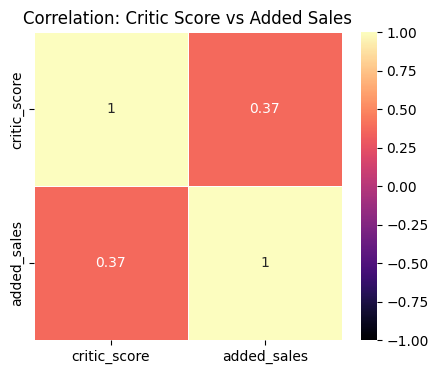

In [23]:
# Checking for correlation between score and sales

plt.figure(figsize=(5,4))

sns.heatmap(
    scored_sales[['critic_score', 'added_sales']].corr(),
    annot=True,
    cmap="magma",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

plt.title("Correlation: Critic Score vs Added Sales")
plt.show()

**The heatmap suggests that critic scores is a very weak indicator of sales performance.**

# In conclusion:

This analysis explored global video game sales across platforms, genres, and time from the perspective of a **Business Analyst at a video game publishing company**, with the goal of identifying patterns that can support commercial decision-making.

Several consistent insights emerged.

1. A small number of genres-primarily **Action, Shooter, and Sports**-account for a disproportionately large share of total sales. From a business perspective, this suggests that publishers seeking lower commercial risk may benefit from prioritizing development and marketing investment in genres with historically proven demand, while approaching niche genres as higher-risk or innovation-driven opportunities.

2. Platform sales are not distributed evenly across the market. A small number of dominant consoles generate the majority of sales, with PlayStation platforms consistently outperforming competitors. For publishers, this highlights the importance of prioritizing development and marketing efforts on platforms with large and active player bases, as platform choice appears to be a significant driver of commercial success.

3. while critic scores show some relationship with sales performance, the correlation is not strong enough to suggest that product quality indicators alone determine commercial success. This implies that publishers should not rely solely on critical reception as a predictor of profitability. Factors such as franchise recognition, marketing reach, brand loyalty, and release strategy likely play equally significant roles.

Regional sales differences also suggest that consumer preferences are not globally uniform, reinforcing the importance of **market-specific publishing and marketing strategies** rather than assuming a one-size-fits-all global approach.

It is important to acknowledge limitations in the dataset, including missing values and the exclusion of earlier historical records, which may introduce some bias toward more modern market behavior. However, given the stakeholder perspective of this analysis, this focus improves the practical relevance of the findings.

Overall, the evidence suggests several actionable recommendations for a video game publisher:

- **Prioritize investment in historically strong-performing genres when commercial success is the primary objective**
- **Time major releases around peak platform lifecycle periods**
- **Adapt marketing strategies to regional market preferences**
- **Treat critic reception as one business signal rather than a sole success predictor**
- **Consider brand strength and franchise positioning as critical commercial variables in future analysis**

Future work could expand this analysis by examining franchise effects, publisher-specific performance, marketing expenditure, and consumer engagement metrics to support even more targeted strategic decision-making.